In [ ]:
# EU Electricity Price Analysis
# Source: Eurostat NRG_PC_204
# Author: github.com/melmaur
# Description: Analysis of household electricity prices
# across Mediterranean EU countries (2007-2025)

In [ ]:
OBIETTIVO
Analizzare l'evoluzione dei prezzi dell'elettricità 
per le famiglie nei paesi mediterranei EU dal 2007 
al 2025, usando dati ufficiali Eurostat (NRG_PC_204).

METODOLOGIA
1. Download dataset Eurostat in formato TSV
2. Pulizia dati — separazione colonna composita, 
   conversione valori numerici, gestione valori mancanti
3. Filtri applicati:
   - Tipo energia: elettricità (E7000)
   - Unità: EUR/kWh
   - Tasse: incluse (I_TAX)
   - Consumo: fascia media (KWH2500-4999)
   - Semestre: S2 di ogni anno
4. Paesi selezionati: IT, ES, FR, EL, HR, SI, MT, CY, PT
5. Visualizzazione divisa in due gruppi per chiarezza

OSSERVAZIONI PRINCIPALI
- Spike 2022 evidente in tutti i paesi — crisi energetica
- Italia e Cipro costantemente sopra la media
- Croazia e Malta storicamente i più economici
- Francia mostra crescita sostenuta dal 2020
- Convergenza verso il basso nel 2023-2024 dopo il picco

In [ ]:
TECHNICAL IMPLEMENTATION
- Python 3.12 with Pandas 1.5 and Matplotlib
- Raw data ingestion from compressed TSV format (.tsv.gz)
- Data wrangling: composite index column split, 
  whitespace stripping, numeric conversion with 
  error handling, NaN management for missing 
  country-year observations
- Semestral data resampled to annual (S2) for 
  cleaner trend visualization
- Two-panel grouped visualization based on 
  2024 price levels relative to EU average
- Output: PNG charts at 150dpi, reproducible 
  via single notebook execution

In [2]:
df = pd.read_csv(r'C:\Users\mauro\Downloads\estat_nrg_pc_204.tsv.gz', 
                 compression='gzip', 
                 sep='\t')

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3).to_string())

Shape: (2196, 39)

First 3 rows:
  freq,siec,nrg_cons,unit,tax,currency,geo\TIME_PERIOD 2007-S1  2007-S2  2008-S1  2008-S2  2009-S1  2009-S2  2010-S1  2010-S2  2011-S1  2011-S2  2012-S1  2012-S2  2013-S1  2013-S2  2014-S1  2014-S2  2015-S1  2015-S2  2016-S1  2016-S2  2017-S1  2017-S2  2018-S1  2018-S2   2019-S1  2019-S2   2020-S1   2020-S2   2021-S1   2021-S2  2022-S1   2022-S2   2023-S1   2023-S2   2024-S1   2024-S2   2025-S1   2025-S2 
0                S,E7000,KWH1000-2499,KWH,I_TAX,EUR,AL       :        :        :        :        :        :        :        :   0.1152   0.1157   0.1163   0.1167   0.1156   0.1154   0.1156    0.116   0.0812   0.0819   0.0824   0.0835   0.0844   0.0856        :   0.0910   0.0920 e  0.0933   0.0922 e  0.0920 e  0.0925 e  0.0937 e  0.0941    0.0976    0.1010   0.1089 e   0.1114   0.1150 e   0.1156   0.1175 e
1                S,E7000,KWH1000-2499,KWH,I_TAX,EUR,AT       :   0.2008   0.2005   0.2033   0.2089   0.2101   0.2172   0.2115    0.221   0.2201   0.2

In [3]:
# Split the first column into separate columns
df_split = df.iloc[:, 0].str.split(',', expand=True)
df_split.columns = ['freq', 'siec', 'nrg_cons', 'unit', 'tax', 'currency', 'geo']

# Attach time columns
time_cols = df.columns[1:]
df_clean = pd.concat([df_split, df.iloc[:, 1:].reset_index(drop=True)], axis=1)

print("Columns:", df_clean.columns.tolist())
print("\nUnique countries:", sorted(df_clean['geo'].unique()))
print("\nUnique units:", df_clean['unit'].unique())
print("\nUnique tax:", df_clean['tax'].unique())

Columns: ['freq', 'siec', 'nrg_cons', 'unit', 'tax', 'currency', 'geo', '2007-S1 ', '2007-S2 ', '2008-S1 ', '2008-S2 ', '2009-S1 ', '2009-S2 ', '2010-S1 ', '2010-S2 ', '2011-S1 ', '2011-S2 ', '2012-S1 ', '2012-S2 ', '2013-S1 ', '2013-S2 ', '2014-S1 ', '2014-S2 ', '2015-S1 ', '2015-S2 ', '2016-S1 ', '2016-S2 ', '2017-S1 ', '2017-S2 ', '2018-S1 ', '2018-S2 ', '2019-S1 ', '2019-S2 ', '2020-S1 ', '2020-S2 ', '2021-S1 ', '2021-S2 ', '2022-S1 ', '2022-S2 ', '2023-S1 ', '2023-S2 ', '2024-S1 ', '2024-S2 ', '2025-S1 ', '2025-S2 ']

Unique countries: ['AL', 'AT', 'BA', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EA', 'EE', 'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'GE', 'HR', 'HU', 'IE', 'IS', 'IT', 'LI', 'LT', 'LU', 'LV', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'UA', 'UK', 'XK']

Unique units: ['KWH']

Unique tax: ['I_TAX' 'X_TAX' 'X_VAT']


In [4]:
import matplotlib.pyplot as plt

# Mediterranean EU countries
med_countries = ['IT', 'ES', 'FR', 'GR', 'HR', 'SI', 'MT', 'CY', 'PT']

# Filter: electricity, KWH, all taxes included, medium consumption
df_med = df_clean[
    (df_clean['geo'].isin(med_countries)) &
    (df_clean['tax'] == 'I_TAX') &
    (df_clean['nrg_cons'] == 'KWH2500-4999')
]

print("Filtered rows:", len(df_med))
print("Countries found:", df_med['geo'].unique())

Filtered rows: 24
Countries found: ['CY' 'ES' 'FR' 'HR' 'IT' 'MT' 'PT' 'SI']


In [5]:
# Fix Greece code
med_countries = ['IT', 'ES', 'FR', 'EL', 'HR', 'SI', 'MT', 'CY', 'PT']

# Filter
df_med = df_clean[
    (df_clean['geo'].isin(med_countries)) &
    (df_clean['tax'] == 'I_TAX') &
    (df_clean['nrg_cons'] == 'KWH2500-4999')
]

# Select annual S2 columns only for cleaner view
s2_cols = [c for c in df_med.columns if 'S2' in c]

# Convert to numeric
df_plot = df_med[['geo'] + s2_cols].copy()
for col in s2_cols:
    df_plot[col] = pd.to_numeric(df_plot[col].astype(str).str.strip().str.replace(' e', '').str.replace(':', 'NaN'), errors='coerce')

# Set index
df_plot = df_plot.set_index('geo').T
df_plot.index = [i.strip().replace('-S2', '') for i in df_plot.index]

print(df_plot)

geo       CY      EL      ES      FR      HR      IT      MT      PT      SI  \
2007  0.1573  0.0984  0.1400  0.1222  0.0984     NaN  0.0918  0.1562  0.1116   
2008  0.2040  0.1099  0.1557  0.1203  0.1184  0.2227  0.1536  0.1525  0.1156   
2009  0.1642  0.1032  0.1684  0.1207  0.1164  0.1997  0.1513  0.1594  0.1341   
2010  0.2021  0.1211  0.1851  0.1350  0.1153  0.1920  0.1653  0.1666  0.1426   
2011  0.2413  0.1238  0.2088  0.1422  0.1146  0.2065  0.1666  0.1881  0.1492   
2012  0.2909  0.1418  0.2275  0.1501  0.1384  0.2297  0.1678  0.2063  0.1542   
2013  0.2481  0.1697  0.2273  0.1596  0.1350  0.2323  0.1689  0.2131  0.1657   
2014  0.2356  0.1785  0.2367  0.1702  0.1324  0.2338  0.1248  0.2231  0.1632   
2015  0.1838  0.1771  0.2370  0.1682  0.1312  0.2428  0.1269  0.2285  0.1631   
2016  0.1621  0.1723  0.2284  0.1711  0.1331  0.2261  0.1274  0.2298  0.1629   
2017  0.1826  0.1620  0.2177  0.1756  0.1236  0.2080  0.1298  0.2230  0.1613   
2018  0.2183  0.1646  0.2477  0.1799  0.

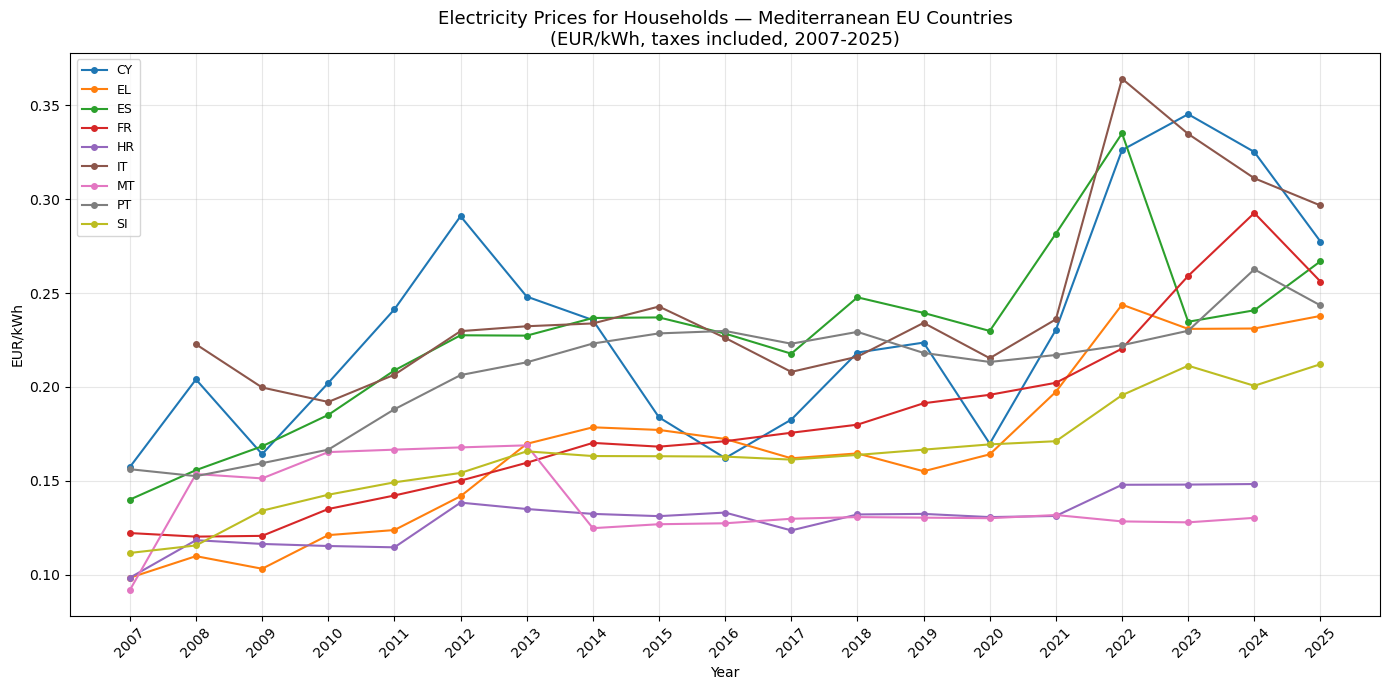

Chart saved!


In [6]:
import matplotlib.pyplot as plt

# Keep only first 9 country columns (avoid duplicates)
df_plot_clean = df_plot.iloc[:, :9]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for country in df_plot_clean.columns:
    ax.plot(df_plot_clean.index, 
            df_plot_clean[country], 
            marker='o', 
            markersize=4,
            label=country)

ax.set_title('Electricity Prices for Households — Mediterranean EU Countries\n(EUR/kWh, taxes included, 2007-2025)', 
             fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('EUR/kWh')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mediterranean_electricity_prices.png', dpi=150)
plt.show()

print("Chart saved!")

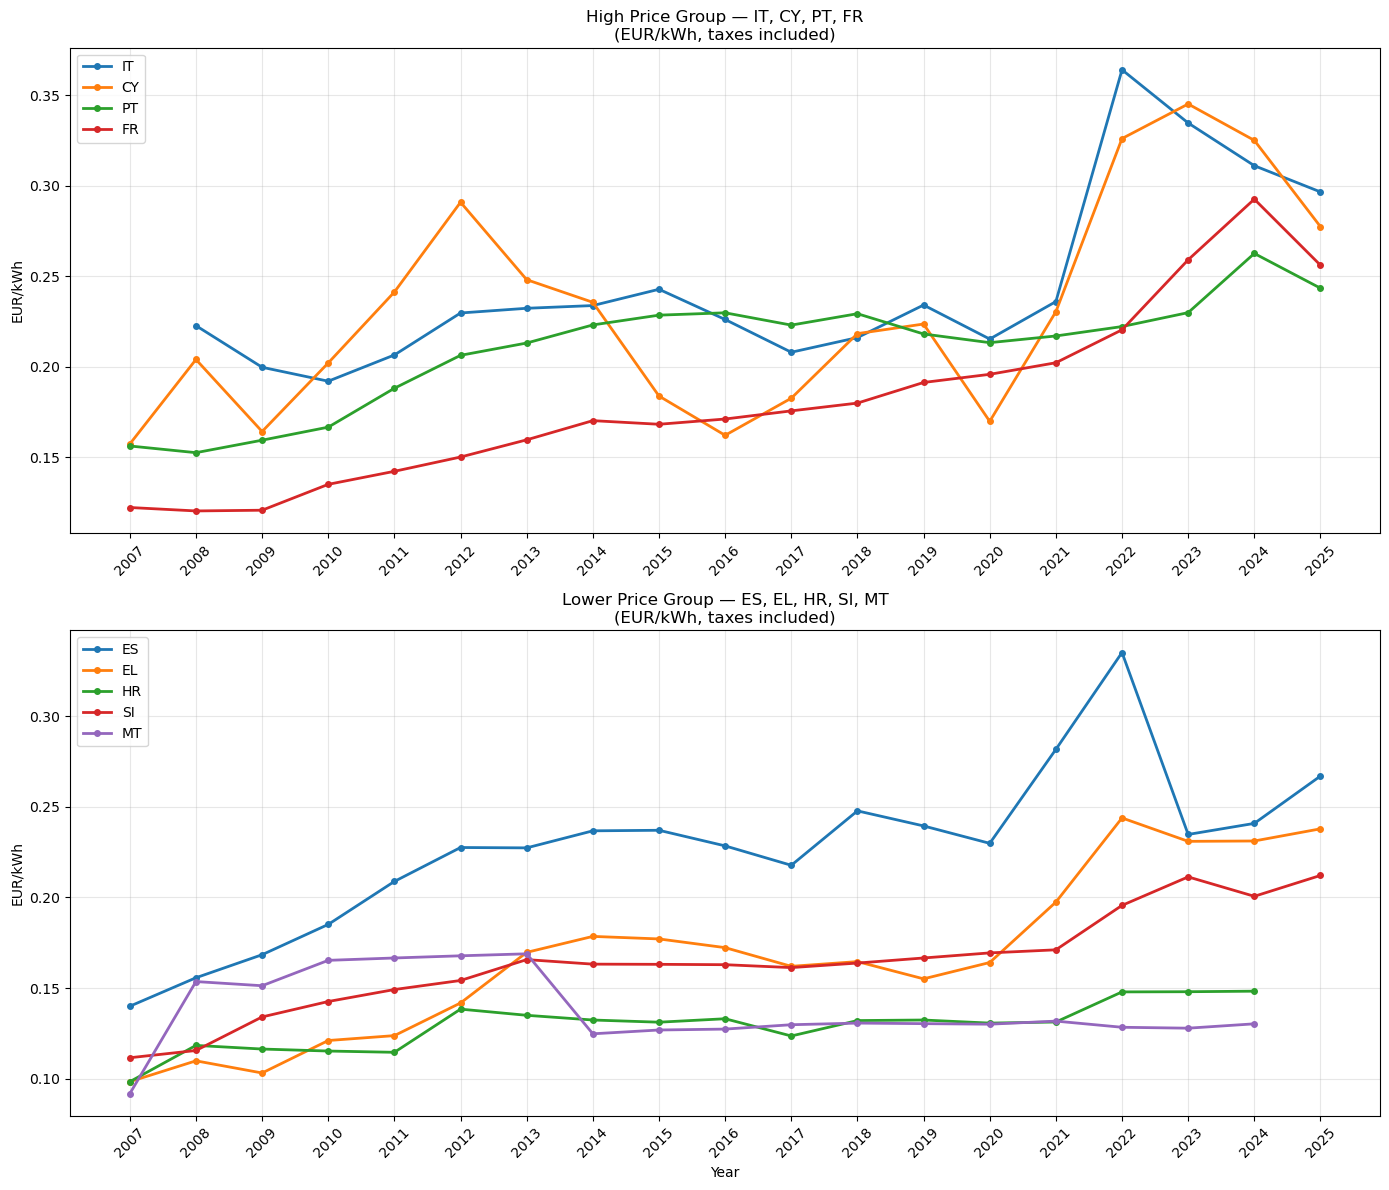

Grouped chart saved!


In [7]:
# Two groups based on 2024 average price
high_price = ['IT', 'CY', 'PT', 'FR']
low_price = ['ES', 'EL', 'HR', 'SI', 'MT']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Group 1 — High price countries
for country in high_price:
    if country in df_plot_clean.columns:
        ax1.plot(df_plot_clean.index,
                df_plot_clean[country],
                marker='o', markersize=4, linewidth=2,
                label=country)

ax1.set_title('High Price Group — IT, CY, PT, FR\n(EUR/kWh, taxes included)',
             fontsize=12)
ax1.set_ylabel('EUR/kWh')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Group 2 — Low price countries
for country in low_price:
    if country in df_plot_clean.columns:
        ax2.plot(df_plot_clean.index,
                df_plot_clean[country],
                marker='o', markersize=4, linewidth=2,
                label=country)

ax2.set_title('Lower Price Group — ES, EL, HR, SI, MT\n(EUR/kWh, taxes included)',
             fontsize=12)
ax2.set_ylabel('EUR/kWh')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mediterranean_electricity_prices_grouped.png', dpi=150)
plt.show()

print("Grouped chart saved!")

In [8]:
# Save charts explicitly to Downloads
import os

output_path = r'C:\Users\mauro\Downloads'

fig1, ax1 = plt.subplots(figsize=(14, 6))
for country in high_price:
    if country in df_plot_clean.columns:
        ax1.plot(df_plot_clean.index,
                df_plot_clean[country],
                marker='o', markersize=4, linewidth=2,
                label=country)
ax1.set_title('High Price Group — IT, CY, PT, FR\n(EUR/kWh, taxes included)', fontsize=12)
ax1.set_ylabel('EUR/kWh')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_high_price.png'), dpi=150)
plt.close()

fig2, ax2 = plt.subplots(figsize=(14, 6))
for country in low_price:
    if country in df_plot_clean.columns:
        ax2.plot(df_plot_clean.index,
                df_plot_clean[country],
                marker='o', markersize=4, linewidth=2,
                label=country)
ax2.set_title('Lower Price Group — ES, EL, HR, SI, MT\n(EUR/kWh, taxes included)', fontsize=12)
ax2.set_ylabel('EUR/kWh')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_low_price.png'), dpi=150)
plt.close()

print("Charts saved to Downloads!")

Charts saved to Downloads!


In [9]:
import os
print("Current working directory:", os.getcwd())


Current working directory: C:\Users\mauro
